# 1. Import bazy danych oraz podstawowa konfiguracja

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Car_Insurance_Claim.csv").dropna(subset="ANNUAL_MILEAGE")
df["GENDER"] = df["GENDER"].astype("category")
df.drop(["RACE", "POSTAL_CODE", "VEHICLE_TYPE", "ID"], axis=1, inplace=True)
df.head()

,AGE,GENDER,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,65+,female,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,12000.0,0,0,0,0.0
1,16-25,male,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,16000.0,0,0,0,1.0
2,16-25,female,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,11000.0,0,0,0,0.0
3,16-25,male,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,11000.0,0,0,0,0.0
4,26-39,male,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,12000.0,2,0,1,1.0


# 2. Edytowanie zmiennych - przygotowanie dla modelu predyckcyjnego

In [3]:
def wiek(wiek_str):
    if wiek_str == "16-25":
        return 21
    elif wiek_str == "26-39":
        return 33
    elif wiek_str == "40-64":
        return 52
    elif wiek_str == "65+":
        return 70

df["AGE"] = df["AGE"].apply(wiek)

In [4]:
def doswiadczenie(dosw_str):
    if dosw_str == "0-9y":
        return 5
    elif dosw_str == "10-19y":
        return 15
    elif dosw_str == "20-29y":
        return 25
    elif dosw_str == "30y+":
        return 35

df["DRIVING_EXPERIENCE"] = df["DRIVING_EXPERIENCE"].apply(doswiadczenie)

In [5]:
def edukacja(edu_str):
    if edu_str == "none":
        return 1
    elif edu_str == "high school":
        return 2
    elif edu_str == "university":
        return 3

df["EDUCATION"] = df["EDUCATION"].apply(edukacja)

In [6]:
def plec(plec_str):
    if plec_str == "male":
        return 0
    elif plec_str == "female":
        return 1

df["GENDER"] = df["GENDER"].apply(plec)

In [7]:
def przychod(przy_str):
    if przy_str == "poverty":
        return 1
    elif przy_str == "working class":
        return 2
    elif przy_str == "middle class":
        return 3
    elif przy_str == "upper class":
        return 4

df["INCOME"] = df["INCOME"].apply(przychod)

In [8]:
def wiek_auta(wa_str):
    if wa_str == "before 2015":
        return 0
    elif wa_str == "after 2015":
        return 1

df["VEHICLE_YEAR"] = df["VEHICLE_YEAR"].apply(wiek_auta)

# 3. Stworzenie kolumny, która będzie sprawdzała czy kierowca popełnił jakiekolwiek naruszenie przepisów

In [9]:
df["HAS_VIOLATIONS"] = 0
warunek = (df["SPEEDING_VIOLATIONS"] != 0) | (df["PAST_ACCIDENTS"] != 0) | (df["DUIS"] != 0)

df.loc[warunek, "HAS_VIOLATIONS"] = 1
df.head()

,AGE,GENDER,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME,HAS_VIOLATIONS
0,70,1,5,2,4,0.629027,1.0,1,0.0,1.0,12000.0,0,0,0,0.0,0
1,21,0,5,1,1,0.357757,0.0,0,0.0,0.0,16000.0,0,0,0,1.0,0
2,21,1,5,2,2,0.493146,1.0,0,0.0,0.0,11000.0,0,0,0,0.0,0
3,21,0,5,3,2,0.206013,1.0,0,0.0,1.0,11000.0,0,0,0,0.0,0
4,33,0,15,1,2,0.388366,1.0,0,0.0,0.0,12000.0,2,0,1,1.0,1


# 4. Przeprowadzenie analizy danych

## a) Macierz korelacji

In [10]:
df.corr()

,AGE,GENDER,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,ANNUAL_MILEAGE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME,HAS_VIOLATIONS
AGE,1.000000,-0.007103,0.702483,0.255579,0.639390,0.488203,0.265692,0.231534,0.378736,0.379954,-0.274368,0.459667,0.283878,0.429072,-0.427021,0.485002
GENDER,-0.007103,1.000000,-0.008701,-0.081091,-0.027959,0.078427,-0.012305,-0.012464,-0.010267,0.000274,0.015845,-0.203578,-0.096611,-0.228696,-0.105643,-0.070184
DRIVING_EXPERIENCE,0.702483,-0.008701,1.000000,0.177011,0.456713,0.344671,0.202326,0.166363,0.265223,0.278600,-0.187520,0.639139,0.400547,0.603102,-0.495759,0.766840
EDUCATION,0.255579,-0.081091,0.177011,1.000000,0.567326,0.416363,0.236263,0.205473,0.197568,0.122594,-0.129150,0.138962,0.091875,0.125034,-0.187763,0.144114
INCOME,0.639390,-0.027959,0.456713,0.567326,1.000000,0.745151,0.423343,0.357014,0.394134,0.289959,-0.263135,0.310516,0.196348,0.285928,-0.417649,0.360731
CREDIT_SCORE,0.488203,0.078427,0.344671,0.416363,0.745151,1.000000,0.312995,0.266157,0.282555,0.221354,-0.174453,0.208433,0.127888,0.182408,-0.321436,0.260948
VEHICLE_OWNERSHIP,0.265692,-0.012305,0.202326,0.236263,0.423343,0.312995,1.000000,0.155296,0.176478,0.120432,-0.097433,0.134071,0.088053,0.119269,-0.385618,0.159939
VEHICLE_YEAR,0.231534,-0.012464,0.166363,0.205473,0.357014,0.266157,0.155296,1.000000,0.131883,0.107001,-0.077363,0.108341,0.051784,0.098375,-0.289614,0.119283
MARRIED,0.378736,-0.010267,0.265223,0.197568,0.394134,0.282555,0.176478,0.131883,1.000000,0.290714,-0.462193,0.218306,0.120351,0.210633,-0.256271,0.220525
CHILDREN,0.379954,0.000274,0.278600,0.122594,0.289959,0.221354,0.120432,0.107001,0.290714,1.000000,-0.447655,0.223971,0.116300,0.205087,-0.233549,0.238145


## b) Histogram roszczeń komunikacyjnych

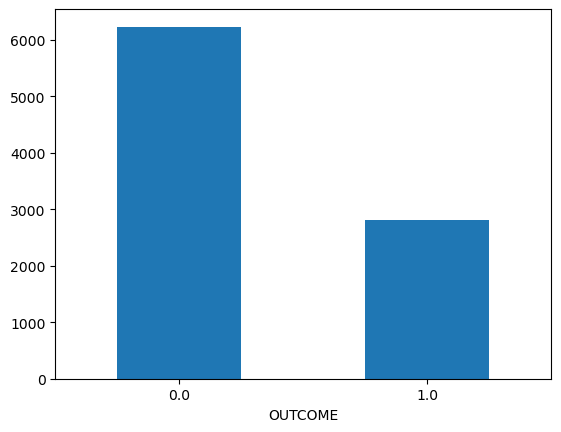

In [50]:
df["OUTCOME"].value_counts().plot.bar(rot=0);

## c) Zgłaszane roszczenia w zależności od wieku

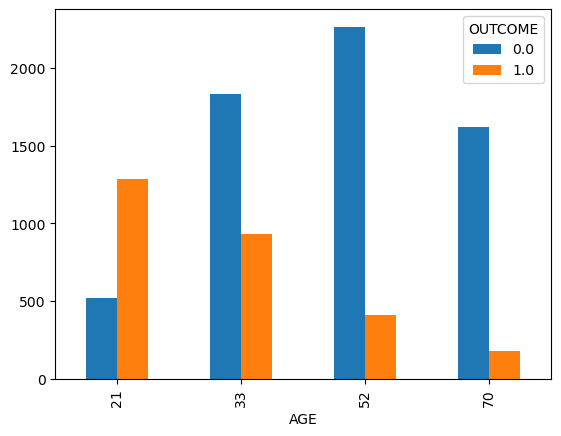

In [39]:
df.groupby(by="OUTCOME")["AGE"].value_counts().unstack(0).plot.bar();

## d) Zgłaszane roszczenia w zależności od doświadczenia

<Axes: xlabel='DRIVING_EXPERIENCE'>

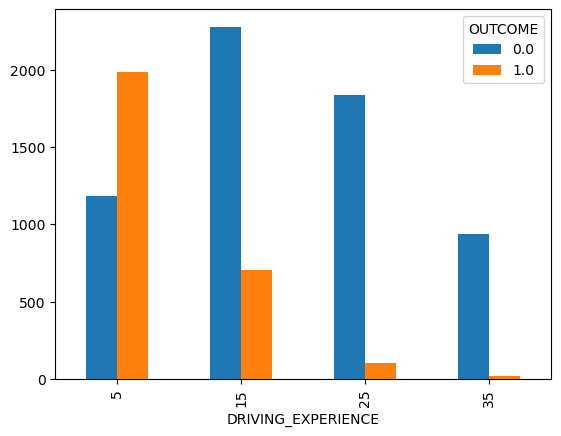

In [34]:
df.groupby(by="OUTCOME")["DRIVING_EXPERIENCE"].value_counts().unstack(0).plot.bar();

## e) Zgłaszane roszczenia w zależności od dochodu

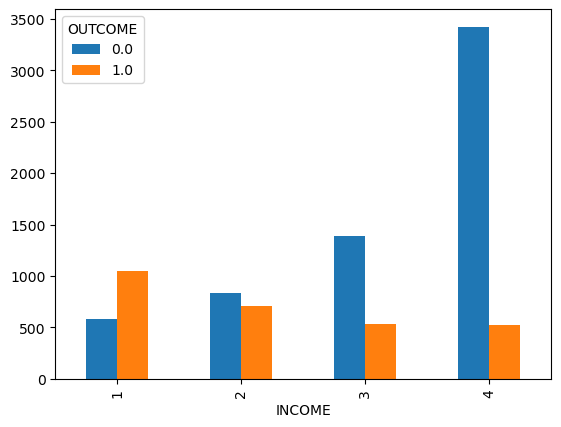

In [36]:
df.groupby(by="OUTCOME")["INCOME"].value_counts().unstack(0).plot.bar();

## f) Zgłaszane roszczenia w zależności od łamania przepisów

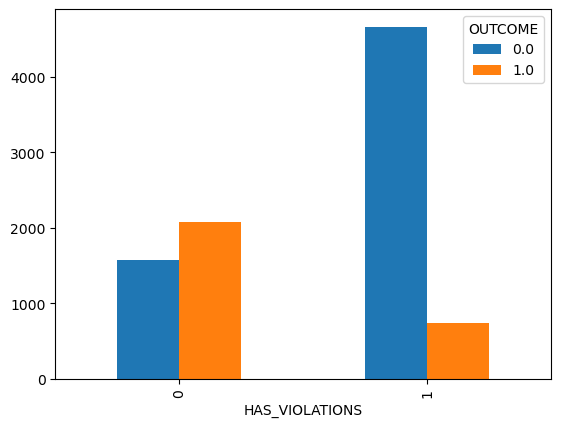

In [37]:
df.groupby(by="OUTCOME")["HAS_VIOLATIONS"].value_counts().unstack(0).plot.bar();

## g) Zgłaszane roszczenia w zależności od posiadania auta

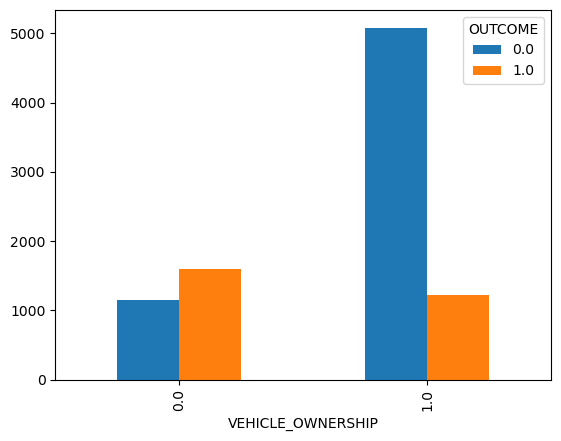

In [48]:
df.groupby(by="OUTCOME")["VEHICLE_OWNERSHIP"].value_counts().unstack(0).plot.bar();

## h) Zgłaszane roszczenia w zależności od wieku auta

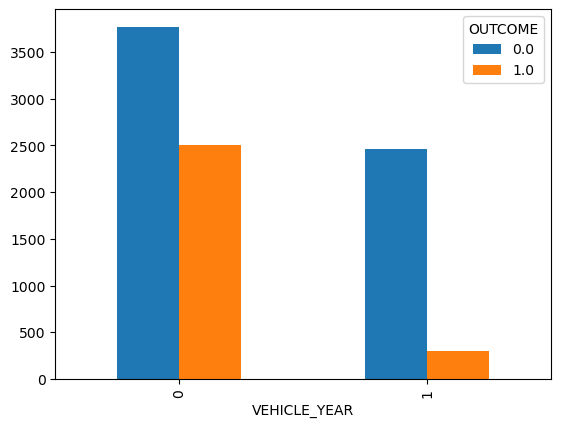

In [49]:
df.groupby(by="OUTCOME")["VEHICLE_YEAR"].value_counts().unstack(0).plot.bar();

# 5. Utworzenie modelu predykcyjnego i sprawdzenie jego dokładności

In [63]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop("OUTCOME", axis=1)
y = df["OUTCOME"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBClassifier(eval_metric='logloss', enable_categorical=True)
model.fit(X_train, y_train)
przewidywania = model.predict(X_test)

In [67]:
macierz_pomylki = pd.crosstab(y_test, przewidywania, 
                         rownames=['Faktyczne'], 
                         colnames=['Przewidziane'], 
                         normalize='index')
print(macierz_pomylki)

Przewidziane         0         1
Faktyczne                       
0.0           0.874801  0.125199
1.0           0.286486  0.713514


# 6. Przeprowadzenie analizy modelu predykcyjnego - sprawdzenie jakie kolumny są najbardziej znaczące

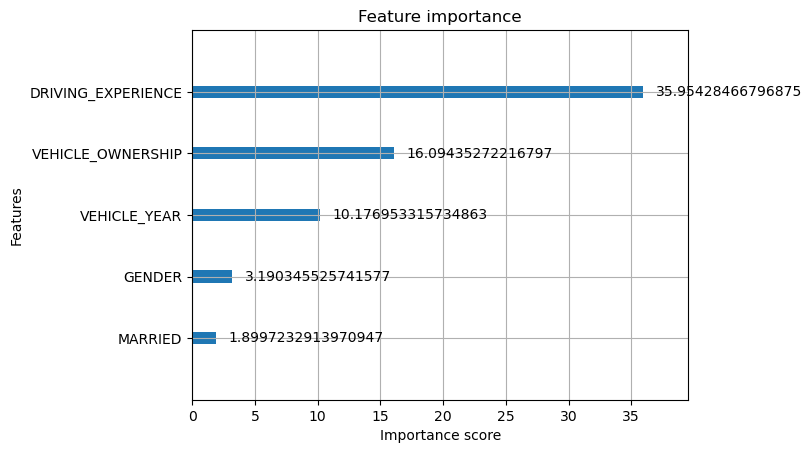

In [68]:
from xgboost import plot_importance

plot_importance(model, importance_type='gain', max_num_features=5)
plt.show()

# 7. Wnioski na podstawie modelu predykcyjnego i analizy danych:
- Model poprawnie identyfikuje klientów bez zgłoszonych szkód w 87% i tych z zgłoszonymi szkodami w 71%
- Najważniejsze 3 czynniki wpływające na dokładność modelu to: doświadczenie kierowcy, czy jest się właścicielem auta oraz wiek auta
- Korelacja nie jest zawsze czynnikiem który powoduje, że dana kolumna będzie miała wyraźny wpływ przy przewidywaniu metodą XGBoost. Kolumna has_violations stworzona przeze mnie miała wysoką korelację (w porównaniu do reszty), a nie miała znaczącego wpływu na wynik